<a href="https://colab.research.google.com/github/marmalux/Telecom-X-Machine-Learning/blob/main/Churn_de_clientes_Telecom_X.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Predición de cancelación de churn de clientes Telecom X

## Importar bibliotecas - general

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## Importar datos y tratamiento

Se importaran datos del proyecto de anáslisis de Telecom X los cuales ya estan limpiados para poder iniciar con la etapa de tratar datos pero para el modelo predictivo.

Además se elimina la columna ID

In [2]:
url_api ="https://github.com/marmalux/Telecom-X-Machine-Learning/raw/refs/heads/main/datos_tratados_Telecom_X.csv"

datos = pd.read_csv(url_api)
datos = datos.drop(['customerID'],axis=1)
datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,...,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Monthly,Charges_Total,Charges_Day,Services_Number
0,0,Female,0,1,1,9,1,No,DSL,No,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,3
1,0,Male,0,0,0,9,1,Yes,DSL,No,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,1
2,1,Male,0,0,0,4,1,No,Fiber optic,No,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,1,Male,1,1,0,13,1,No,Fiber optic,No,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,4
4,1,Female,1,1,0,3,1,No,Fiber optic,No,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,2


## Correlación  

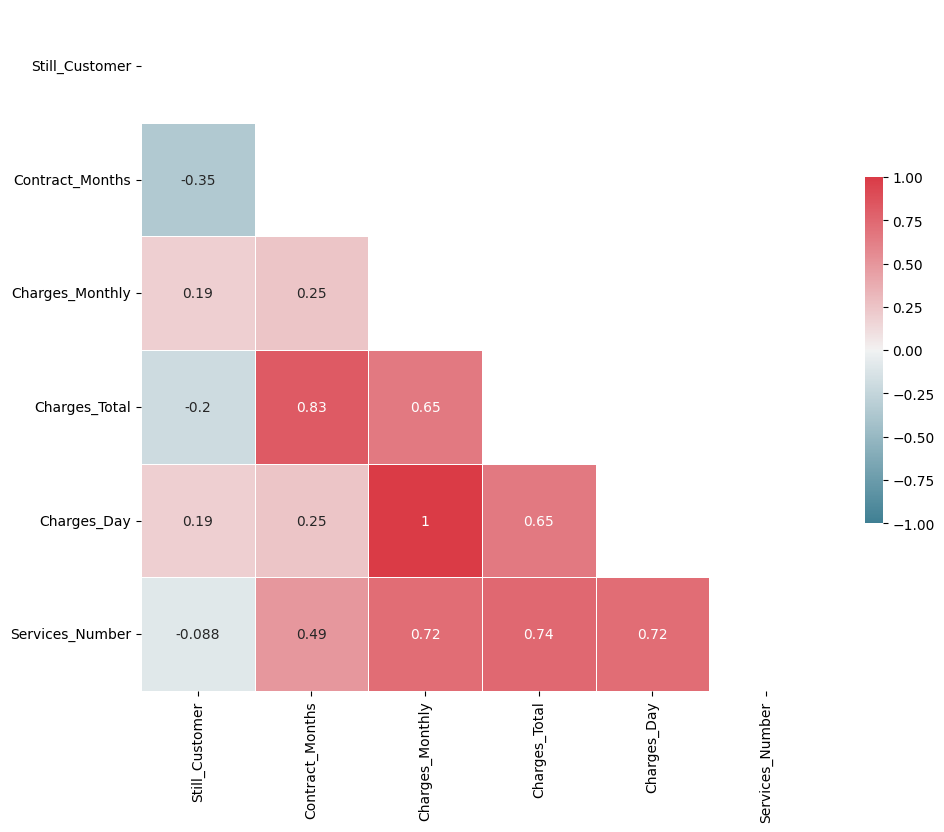

In [3]:
corr = datos[['Still_Customer','Contract_Months','Charges_Monthly','Charges_Total','Charges_Day','Services_Number']].corr()

# ¿Qué factores están más correlacionados?

# Generar una máscara para el triángulo superior
mascara = np.zeros_like(corr, dtype=bool)
mascara[np.triu_indices_from(mascara)] = True

# Configurar la figura de matplotlib
f, ax = plt.subplots(figsize=(11, 9))

# Generar el mapa de calor (heatmap)
cmap = sns.diverging_palette(220, 10, as_cmap=True)

sns.heatmap(corr, mask=mascara, cmap=cmap, vmax=1, vmin=-1, center=0,
            square=True, linewidths=.5, annot=True, cbar_kws={"shrink": .5})

plt.show()

A partir de esta pequeña correlacion se puede ver que las columnas 'Charges_Monthly', 'Charges_Day', 'Charges_Total' tienen una relacion mas directa que pueden perjudicar al modelo por lo que solo se deja uno de ellos, además, 'Services_Number' tambien puede perjudicar al modelo pues surge a partir de los servicios mostrados, por lo que tambien se elimina

In [4]:
datos = datos.drop(['Charges_Monthly','Charges_Day','Services_Number'], axis=1)
datos.head(4)

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,0,Female,0,1,1,9,1,No,DSL,No,Yes,No,Yes,Yes,No,One year,1,Mailed check,593.30
1,0,Male,0,0,0,9,1,Yes,DSL,No,No,No,No,No,Yes,Month-to-month,0,Mailed check,542.40
2,1,Male,0,0,0,4,1,No,Fiber optic,No,No,Yes,No,No,No,Month-to-month,1,Electronic check,280.85
3,1,Male,1,1,0,13,1,No,Fiber optic,No,Yes,Yes,No,Yes,Yes,Month-to-month,1,Electronic check,1237.85


### Mapear datos para modelo

Columnas como 'Online_Security' tiene un valor extra 'No internet service' que no se necesita debido a que esto depende mas de la columna 'Internet_Service' asi que se puede quitar este valor para dejarlo como 'Yes' y 'No' para intentar mejorar el modelo

In [5]:
len('')

0

In [6]:
columnas = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies']

# se usan columnas que tengan mas que 'yes' y 'no'
for col in columnas:
# for col in columnas_binarias:
    datos[col] = datos[col].replace({"No internet service":"No","No phone service":"No"})
    datos[col] = datos[col].map({"Yes":1,"No":0})

columnas = ['Multiple_Lines', 'Online_Security', 'Online_Backup',
       'Device_Protection', 'Tech_Support', 'Streaming_TV', 'Streaming_Movies',
            'Still_Customer','Partner', 'Dependents','Paperless_Billing']

datos.head()

,Still_Customer,Gender,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Internet_Service,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Contract_type,Paperless_Billing,Payment_Method,Charges_Total
0,0,Female,0,1,1,9,1,0,DSL,0,1,0,1,1,0,One year,1,Mailed check,593.30
1,0,Male,0,0,0,9,1,1,DSL,0,0,0,0,0,1,Month-to-month,0,Mailed check,542.40
2,1,Male,0,0,0,4,1,0,Fiber optic,0,0,1,0,0,0,Month-to-month,1,Electronic check,280.85
3,1,Male,1,1,0,13,1,0,Fiber optic,0,1,1,0,1,1,Month-to-month,1,Electronic check,1237.85
4,1,Female,1,1,0,3,1,0,Fiber optic,0,0,0,1,1,0,Month-to-month,1,Mailed check,267.40


In [7]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 19 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Still_Customer     7043 non-null   int64  
 1   Gender             7043 non-null   object 
 2   Senior_Citizen     7043 non-null   int64  
 3   Partner            7043 non-null   int64  
 4   Dependents         7043 non-null   int64  
 5   Contract_Months    7043 non-null   int64  
 6   Phone_Service      7043 non-null   int64  
 7   Multiple_Lines     7043 non-null   int64  
 8   Internet_Service   7043 non-null   object 
 9   Online_Security    7043 non-null   int64  
 10  Online_Backup      7043 non-null   int64  
 11  Device_Protection  7043 non-null   int64  
 12  Tech_Support       7043 non-null   int64  
 13  Streaming_TV       7043 non-null   int64  
 14  Streaming_Movies   7043 non-null   int64  
 15  Contract_type      7043 non-null   object 
 16  Paperless_Billing  7043 

### Distribución churn clientes

In [8]:
estadisticas_columnas=datos.describe() # se almacena el dataframe en una variable para poder usar estos datos despues
datos.describe()

,Still_Customer,Senior_Citizen,Partner,Dependents,Contract_Months,Phone_Service,Multiple_Lines,Online_Security,Online_Backup,Device_Protection,Tech_Support,Streaming_TV,Streaming_Movies,Paperless_Billing,Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.265370,0.162147,0.483033,0.299588,32.371149,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,2279.734304
std,0.441561,0.368612,0.499748,0.458110,24.559481,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,9.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,398.550000
50%,0.000000,0.000000,0.000000,0.000000,29.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1394.550000
75%,1.000000,0.000000,1.000000,1.000000,55.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8684.800000


In [9]:
porcentaje_churn = estadisticas_columnas.loc['mean','Still_Customer']

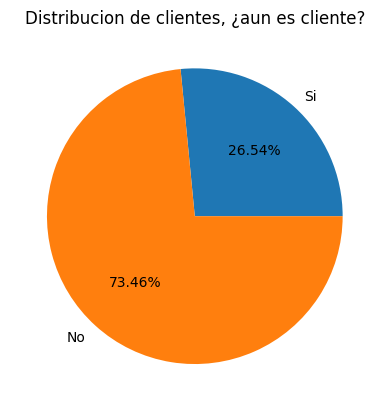

In [10]:
porcentaje_churn = estadisticas_columnas.loc['mean','Still_Customer']

fig, ax=plt.subplots()
ax.pie(x=[porcentaje_churn,1-porcentaje_churn],labels=['Si','No'],autopct='%0.2f%%')
ax.set_title('Distribucion de clientes, ¿aun es cliente?')
plt.show()
fig.savefig('distribucion_clientes.png')

## Encoding

In [11]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import make_column_transformer   #para aplicar propiedades especificas a columnas especificas

categoricas = ['Gender','Internet_Service','Contract_type','Payment_Method']

one_hot_enc = make_column_transformer(
    (OneHotEncoder(handle_unknown='ignore'),
    categoricas),
    remainder='passthrough')

datos = one_hot_enc.fit_transform(datos)    #ajusta el transformador de datos y luego transforma con fit_transform
datos = pd.DataFrame(datos, columns=one_hot_enc.get_feature_names_out())
datos

,onehotencoder__Gender_Female,onehotencoder__Gender_Male,onehotencoder__Internet_Service_DSL,onehotencoder__Internet_Service_Fiber optic,onehotencoder__Internet_Service_No,onehotencoder__Contract_type_Month-to-month,onehotencoder__Contract_type_One year,onehotencoder__Contract_type_Two year,onehotencoder__Payment_Method_Bank transfer (automatic),onehotencoder__Payment_Method_Credit card (automatic),...,remainder__Phone_Service,remainder__Multiple_Lines,remainder__Online_Security,remainder__Online_Backup,remainder__Device_Protection,remainder__Tech_Support,remainder__Streaming_TV,remainder__Streaming_Movies,remainder__Paperless_Billing,remainder__Charges_Total
0,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,593.30
1,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,542.40
2,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,280.85
3,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,1.0,0.0,1.0,1.0,1.0,1237.85
4,1.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,267.40
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,742.90
7039,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,1873.70
7040,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,92.75
7041,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,4627.65


In [12]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 27 columns):
 #   Column                                                   Non-Null Count  Dtype  
---  ------                                                   --------------  -----  
 0   onehotencoder__Gender_Female                             7043 non-null   float64
 1   onehotencoder__Gender_Male                               7043 non-null   float64
 2   onehotencoder__Internet_Service_DSL                      7043 non-null   float64
 3   onehotencoder__Internet_Service_Fiber optic              7043 non-null   float64
 4   onehotencoder__Internet_Service_No                       7043 non-null   float64
 5   onehotencoder__Contract_type_Month-to-month              7043 non-null   float64
 6   onehotencoder__Contract_type_One year                    7043 non-null   float64
 7   onehotencoder__Contract_type_Two year                    7043 non-null   float64
 8   onehotencoder__Payment_Metho

In [13]:
datos.describe()

,onehotencoder__Gender_Female,onehotencoder__Gender_Male,onehotencoder__Internet_Service_DSL,onehotencoder__Internet_Service_Fiber optic,onehotencoder__Internet_Service_No,onehotencoder__Contract_type_Month-to-month,onehotencoder__Contract_type_One year,onehotencoder__Contract_type_Two year,onehotencoder__Payment_Method_Bank transfer (automatic),onehotencoder__Payment_Method_Credit card (automatic),...,remainder__Phone_Service,remainder__Multiple_Lines,remainder__Online_Security,remainder__Online_Backup,remainder__Device_Protection,remainder__Tech_Support,remainder__Streaming_TV,remainder__Streaming_Movies,remainder__Paperless_Billing,remainder__Charges_Total
count,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,...,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.495244,0.504756,0.343746,0.439585,0.216669,0.550192,0.209144,0.240664,0.219225,0.216101,...,0.903166,0.421837,0.286668,0.344881,0.343888,0.290217,0.384353,0.387903,0.592219,2279.734304
std,0.500013,0.500013,0.474991,0.496372,0.412004,0.497510,0.406726,0.427517,0.413751,0.411613,...,0.295752,0.493888,0.452237,0.475363,0.475038,0.453895,0.486477,0.487307,0.491457,2266.794470
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,398.550000
50%,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,1394.550000
75%,1.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,3786.600000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,8684.800000


## Análisis de correlacion y dirigido a distintas variables

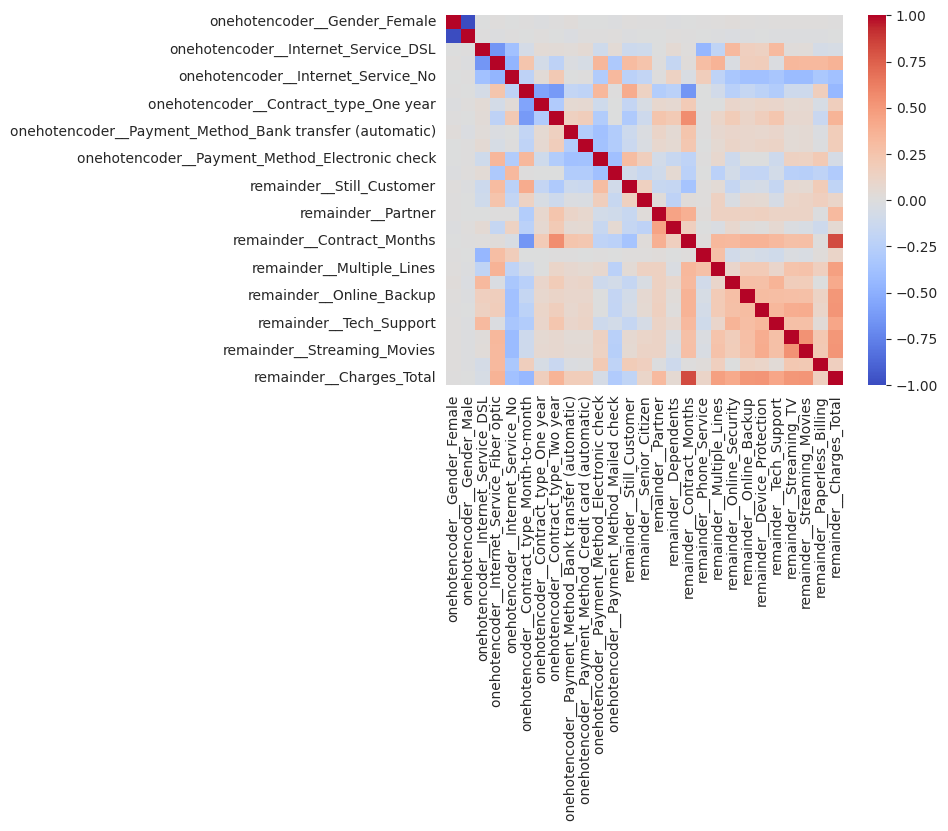

In [48]:
cor =datos.corr()
cor_im = sns.heatmap(cor,cmap='coolwarm');
plt.savefig('correlacion_heatmap.png',  bbox_inches='tight')

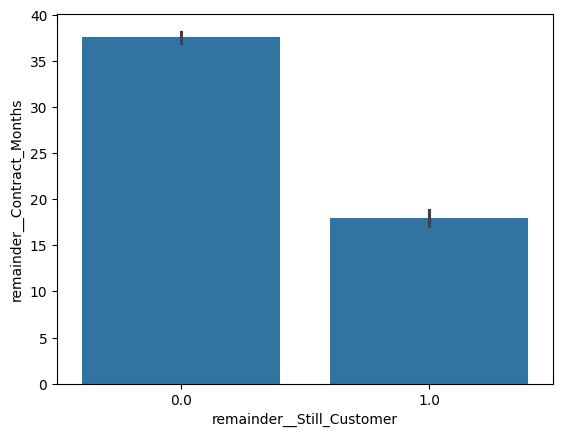

In [15]:
sns.barplot(data=datos,x='remainder__Still_Customer',y='remainder__Contract_Months');


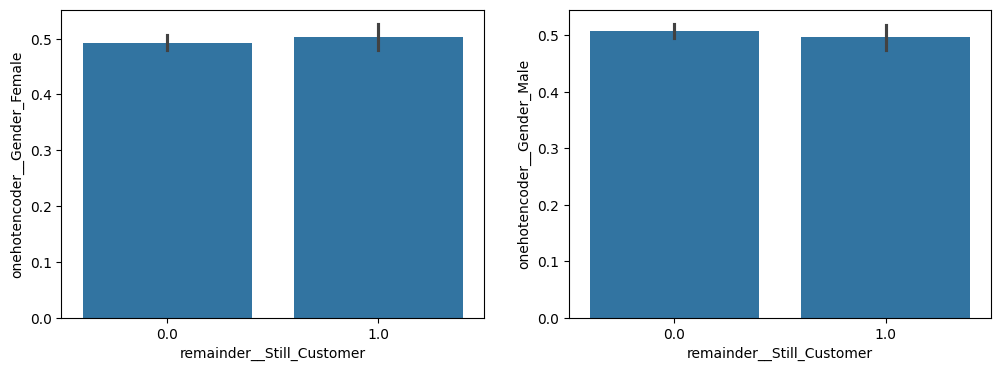

In [16]:
fig, ax = plt.subplots(1,2,figsize = (12,4))
sns.barplot(data=datos,x='remainder__Still_Customer',y='onehotencoder__Gender_Female',ax=ax[0]);
sns.barplot(data=datos,x='remainder__Still_Customer',y='onehotencoder__Gender_Male',ax=ax[1]);

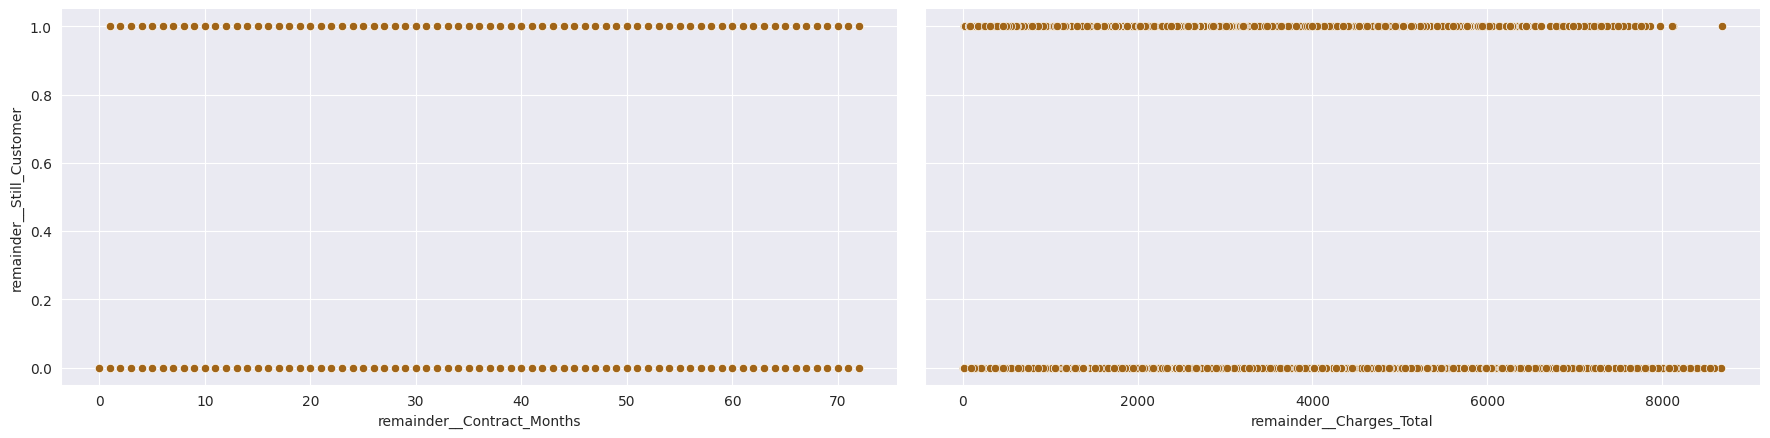

In [17]:
sns.set_palette('BrBG')
# style -> white, dark, whitegrid, darkgrid, ticks
sns.set_style('darkgrid')

ax = sns.pairplot(data=datos,y_vars='remainder__Still_Customer',x_vars = ['remainder__Contract_Months','remainder__Charges_Total']);
ax.figure.set_size_inches(20,5)

ax;

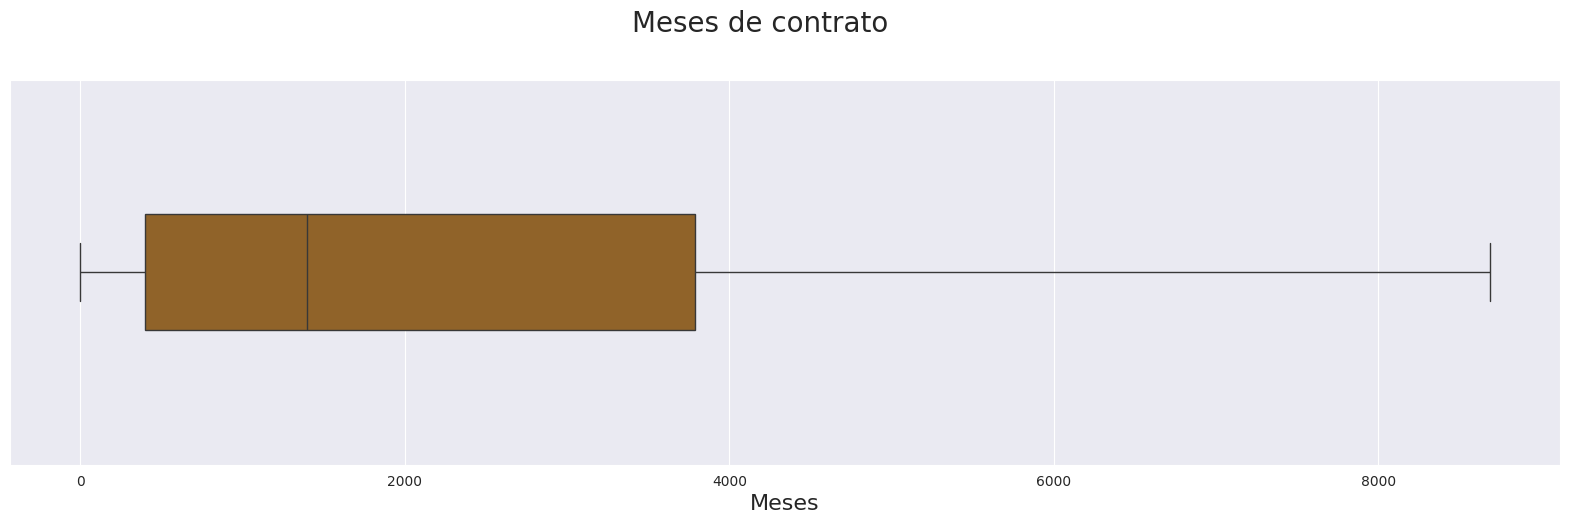

In [18]:
ax = sns.boxplot(data=datos['remainder__Charges_Total'],orient='h',width=0.3)
ax.figure.set_size_inches(20,5)
ax.figure.suptitle('Meses de contrato',fontsize = 20,y=1.02)
ax.set_xlabel('Meses',fontsize = 16)
ax;

## Modelado predictivo

Separar los datos para trabajar con el modelo

In [19]:
from sklearn.model_selection import train_test_split

X = datos.drop(['remainder__Still_Customer'],axis=1)
y = datos['remainder__Still_Customer']

#dividir los datos para prueba
X_train,X_test,y_train, y_test = train_test_split(X,y,stratify=y,test_size=0.3, random_state=10)

### Modelos

Para crear los modelos se considera una validacion cruzada con StratifiedKFold, asi como el balanceo tanto 'undersampling' como 'oversampling' para comparar resultados y usando un pipeline para mejorar resultados tanto el resultado del modelo como el codigo empleado

#### Modelo KNN

Este algoritmo se basa en el cálculo de las distancias en los registros de la base de datos debido a esto hay variables que pueden afectar debido al número que tiene y que puede opacar a las variables, por lo que se puede normalizar los datos para poder trabajar mejor con ellos, además del desvalance que también se aplica debido a que tambien puede influir en el modelo.

In [20]:
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import StratifiedKFold,cross_validate

#estratificacion
skf = StratifiedKFold(n_splits = 5,shuffle = True, random_state=10)

In [21]:
#normalizar
from sklearn.preprocessing import MinMaxScaler
normalizacion = MinMaxScaler()
X_train_normalizado = normalizacion.fit_transform(X_train)
X_test_normalizado = normalizacion.fit_transform(X_test)    #para probar el modelo

In [22]:
pd.DataFrame(X_train_normalizado).head(3) #la matriz queda entre valores 0 y uno dejando todos en la misma escala

,0,1,2,3,4,5,6,7,8,9,...,16,17,18,19,20,21,22,23,24,25
0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,...,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,0.643538
1,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.094316
2,1.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,...,1.0,1.0,1.0,1.0,1.0,1.0,1.0,0.0,1.0,0.211924


In [23]:
# Modelo KNN
from sklearn.neighbors import KNeighborsClassifier
knn = KNeighborsClassifier()

#metricas
metricas = ['accuracy','recall','f1','roc_auc']
balances = [SMOTE(),NearMiss(version=3)]
# funcion para probar modelos
def probar_modelo(balanceo,modelo,normalizar=None):
  pipeline = imbpipeline([('normalizar',normalizar),('balanceo',balanceo),('modelo',modelo)])

  cv_resultados = cross_validate(pipeline,X,y,cv=skf,scoring=metricas)
  return cv_resultados


In [24]:
prueba_knn_smote = (probar_modelo(SMOTE(),knn,normalizacion))
prueba_knn_nearmiss = probar_modelo(NearMiss(version = 3),knn,normalizacion)

In [25]:
resumen_modelos_knn = pd.DataFrame({
    "KNN + SMOTE": pd.DataFrame(prueba_knn_smote).mean(),
    "KNN + NearMiss_V3": pd.DataFrame(prueba_knn_nearmiss).mean()
}).T
resumen_modelos_knn

,fit_time,score_time,test_accuracy,test_recall,test_f1,test_roc_auc
KNN + SMOTE,0.078137,0.417460,0.689763,0.715347,0.550269,0.757743
KNN + NearMiss_V3,0.129049,0.139468,0.716173,0.608358,0.532211,0.724126


#### Modelo Random Forest

El modelo RandomForest consiste en clasificar los datos dependiendo de un rango claculado para poder establecerlo en un determinado valor.

In [26]:
from sklearn.ensemble import RandomForestClassifier

forest = RandomForestClassifier(max_depth=5)

In [27]:
#pipeline
prueba_forest_smote = probar_modelo(SMOTE(),forest,normalizacion)
prueba_forest_nearmiss = probar_modelo(NearMiss(version=3),forest,normalizacion)

In [28]:
resumen_modelos_forest = pd.DataFrame({
    "forest + SMOTE": pd.DataFrame(prueba_forest_smote).mean(),
    "forest + NearMiss_V3": pd.DataFrame(prueba_forest_nearmiss).mean()
}).T
resumen_modelos_forest

,fit_time,score_time,test_accuracy,test_recall,test_f1,test_roc_auc
forest + SMOTE,1.156505,0.098887,0.747693,0.802568,0.627823,0.843833
forest + NearMiss_V3,0.327658,0.044982,0.778505,0.636713,0.603949,0.827322


## Comparación de modelos

In [29]:
resumen_modelos = pd.DataFrame({
    "KNN + SMOTE": pd.DataFrame(prueba_forest_smote).mean(),
    "KNN + NearMiss_V3": pd.DataFrame(prueba_forest_nearmiss).mean()
}).T
resumen_modelos

,fit_time,score_time,test_accuracy,test_recall,test_f1,test_roc_auc
KNN + SMOTE,1.156505,0.098887,0.747693,0.802568,0.627823,0.843833
KNN + NearMiss_V3,0.327658,0.044982,0.778505,0.636713,0.603949,0.827322


In [31]:
pd.concat([resumen_modelos_knn, resumen_modelos_forest])

,fit_time,score_time,test_accuracy,test_recall,test_f1,test_roc_auc
KNN + SMOTE,0.078137,0.417460,0.689763,0.715347,0.550269,0.757743
KNN + NearMiss_V3,0.129049,0.139468,0.716173,0.608358,0.532211,0.724126
forest + SMOTE,1.156505,0.098887,0.747693,0.802568,0.627823,0.843833
forest + NearMiss_V3,0.327658,0.044982,0.778505,0.636713,0.603949,0.827322


## Eligiendo modelo

Para elegir el modelo se deben tomar en cuenta las métricas mas adecuadas, en este caso se toma en cuenta, en primer lugar 'accuracy' mide que tan bien se acierta el churn pero al estar un poco desbalanceado (26% mas o menos de que si es cliente) entonces no es muy confiable.

**Recall y f1**

Al usar 'recall' y 'f1' podemos determinar que con 'recall' detectar quienes si se fueron, es decir cuantos verdaderos negativos fue capaz de predecir el modelo y con 'f1' se detecta el churn tambien pero al ser un balance entre 'recall' y 'precision' evitando los falsos positivos y falsos negativos.

**ROC_AUC**

Indica que tan bien separa los que son churn de los que no por lo que un valor mas cercano a 1 es mas conveniente

### Modelo elegido

Debido a las consideraciones de las metricas se observa que el modelo con mejor 'recall' y 'f1' score es el modelo ***RandomForest*** con balanceo de oversampling SMOTE aunque no tiene el mejor valor de precisión pero para este caso es el mejor modelo para predecir el churn de clientes.

## Prueba de modelo

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

forest = RandomForestClassifier(max_depth = 5,random_state=10)
modelo_forest = imbpipeline([("balanceo", SMOTE(random_state=10)),("modelo", forest)])

#entrenar modelo
modelo_forest.fit(X_train,y_train)

Pipeline(steps=[('balanceo', SMOTE(random_state=10)),
                ('modelo',
                 RandomForestClassifier(max_depth=5, random_state=10))])

              precision    recall  f1-score   support

         0.0       0.88      0.80      0.84      1552
         1.0       0.56      0.70      0.62       561

    accuracy                           0.77      2113
   macro avg       0.72      0.75      0.73      2113
weighted avg       0.80      0.77      0.78      2113



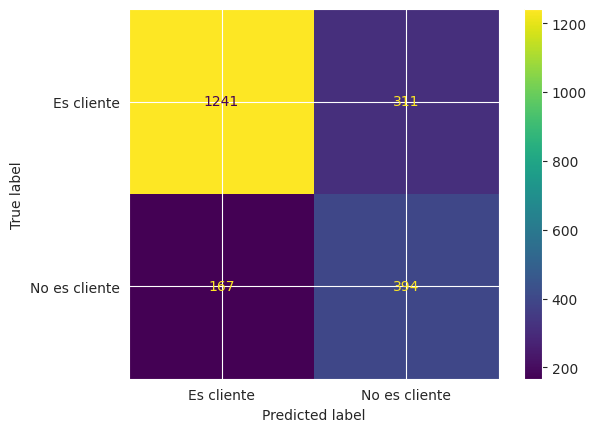

In [50]:
from sklearn.metrics import classification_report
y_predicto = modelo_forest.predict(X_test)

print(classification_report(y_test,y_predicto))
ConfusionMatrixDisplay.from_predictions(y_test,y_predicto,display_labels=['Es cliente','No es cliente']);
plt.savefig('matriz_confusion.png')

In [40]:
importances = forest.feature_importances_

In [41]:
feature_importances = pd.DataFrame({'Features':X.columns,
                                    'Importances':(importances*100).round(4)}).sort_values('Importances',ascending=False)
feature_importances

,Features,Importances
10,onehotencoder__Payment_Method_Electronic check,19.0154
5,onehotencoder__Contract_type_Month-to-month,17.9889
3,onehotencoder__Internet_Service_Fiber optic,11.6381
7,onehotencoder__Contract_type_Two year,7.7259
15,remainder__Contract_Months,7.5331
24,remainder__Paperless_Billing,5.0145
6,onehotencoder__Contract_type_One year,4.5073
4,onehotencoder__Internet_Service_No,4.2457
21,remainder__Tech_Support,3.8270
25,remainder__Charges_Total,3.7130


Podemos ver que las variables mas significativas para el modelo forest influye mas la forma de pago, la forma de tiempo de contrato (mes a mes mayor que el por año) y que servicio de internet se esta usando

### Guardar modelo

In [43]:
import pickle

try:
  with open('champion.pkl','wb') as file:
    pickle.dump(modelo_forest,file)
  print('modelo serializado con exito')
except exception as e:
  print('Se presento error al realizar el modelo')

modelo serializado con exito


## Conclusión

Basandonos en las variables del modelo podemos ver que lo que mas influye para detectar si es cliente o no, el modelo predice el no churn o que se mantiene como cliente es el método de pago si es por cheque electrónico, que se da mas en el contrato de mes a mes, al menos mas que el que es por dos años, los que contratan internet por fibra optica, los que no tienen un servicio de internet, además de soporte.

Estas son las variables que mas afectan y que ayudan a dicernir mejor si el cliente se va o se queda, por lo que tomar una decisión a partir de estas variables para un mejor control en la retención de clientes